In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Loading the dataset
df = pd.read_csv("adult_with_headers (1).csv")
df.tail()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K
32560,52,Self-emp-inc,287927,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,40,United-States,>50K


Skewness in numerical columns:
capital_gain      11.953848
capital_loss       4.594629
fnlwgt             1.446980
age                0.558743
hours_per_week     0.227643
education_num     -0.311676
dtype: float64


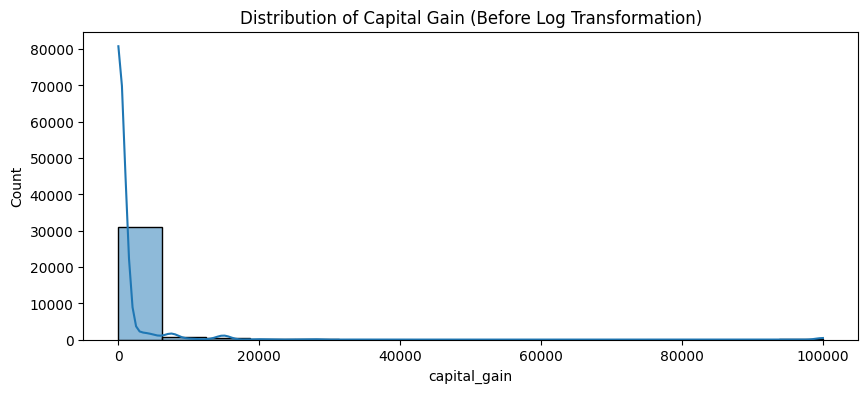

In [24]:
# Checking skewness of numerical features
numerical_cols = ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']
skewness = df[numerical_cols].skew().sort_values(ascending=False)
print('Skewness in numerical columns:')
print(skewness)

# Visualizing the distribution of capital_gain as it is usually highly skewed
plt.figure(figsize=(10, 4))
sns.histplot(df['capital_gain'], kde=True)
plt.title('Distribution of Capital Gain (Before Log Transformation)')
plt.show()

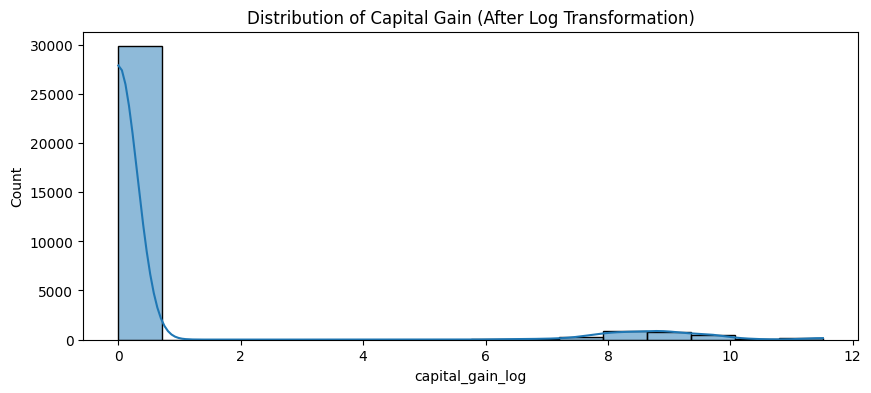

,capital_gain,capital_gain_log
0,2174,7.684784
1,0,0.000000
2,0,0.000000
3,0,0.000000
4,0,0.000000


In [25]:
# Applying Log Transformation to 'capital_gain'
# We use log1p (log(1+x)) because capital_gain contains many zeros
df['capital_gain_log'] = df['capital_gain'].apply(np.log1p)

# Visualizing the distribution after transformation
plt.figure(figsize=(10, 4))
sns.histplot(df['capital_gain_log'], kde=True)
plt.title('Distribution of Capital Gain (After Log Transformation)')
plt.show()

display(df[['capital_gain', 'capital_gain_log']].head())

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               32561 non-null  int64  
 1   workclass         32561 non-null  object 
 2   fnlwgt            32561 non-null  int64  
 3   education         32561 non-null  object 
 4   education_num     32561 non-null  int64  
 5   marital_status    32561 non-null  object 
 6   occupation        32561 non-null  object 
 7   relationship      32561 non-null  object 
 8   race              32561 non-null  object 
 9   sex               32561 non-null  object 
 10  capital_gain      32561 non-null  int64  
 11  capital_loss      32561 non-null  int64  
 12  hours_per_week    32561 non-null  int64  
 13  native_country    32561 non-null  object 
 14  income            32561 non-null  object 
 15  capital_gain_log  32561 non-null  float64
dtypes: float64(1), int64(6), object(9)
memor

In [9]:
df.isna().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education_num,0
marital_status,0
occupation,0
relationship,0
race,0
sex,0


In [10]:
from sklearn.preprocessing import StandardScaler
scale=StandardScaler()
m=df.select_dtypes(include=["int64"]).columns
x_scale=scale.fit_transform(df[m])
x_scale=pd.DataFrame(x_scale,columns=m)
x_scale.head()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
0,0.030671,-1.063611,1.134739,0.148453,-0.21666,-0.035429
1,0.837109,-1.008707,1.134739,-0.145920,-0.21666,-2.222153
2,-0.042642,0.245079,-0.420060,-0.145920,-0.21666,-0.035429
3,1.057047,0.425801,-1.197459,-0.145920,-0.21666,-0.035429
4,-0.775768,1.408176,1.134739,-0.145920,-0.21666,-0.035429


In [11]:
#using stadedization for removing unit free values and meann =0 and

In [12]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler
min=scale.fit_transform(x_scale)
min=pd.DataFrame(min,columns=m)
min.head()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
0,0.030671,-1.063611,1.134739,0.148453,-0.21666,-0.035429
1,0.837109,-1.008707,1.134739,-0.145920,-0.21666,-2.222153
2,-0.042642,0.245079,-0.420060,-0.145920,-0.21666,-0.035429
3,1.057047,0.425801,-1.197459,-0.145920,-0.21666,-0.035429
4,-0.775768,1.408176,1.134739,-0.145920,-0.21666,-0.035429


In [13]:
#minmaxscaler is future scaling  using for the minium range 0 and maximum range 1

In [14]:
cat_data=df.select_dtypes(include=["object"])
label_encod=cat_data.drop(columns=["race","sex"])
#m=cat_data.drop(cat_data.columns[[6,5,8]],axis=1)
label_encod


,workclass,education,marital_status,occupation,relationship,native_country,income
0,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,United-States,<=50K
1,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,United-States,<=50K
2,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,United-States,<=50K
3,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,United-States,<=50K
4,Private,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Cuba,<=50K
...,...,...,...,...,...,...,...
32556,Private,Assoc-acdm,Married-civ-spouse,Tech-support,Wife,United-States,<=50K
32557,Private,HS-grad,Married-civ-spouse,Machine-op-inspct,Husband,United-States,>50K
32558,Private,HS-grad,Widowed,Adm-clerical,Unmarried,United-States,<=50K
32559,Private,HS-grad,Never-married,Adm-clerical,Own-child,United-States,<=50K


In [15]:
ohe_data=cat_data[["race","sex","income"]]
ohe_data

,race,sex,income
0,White,Male,<=50K
1,White,Male,<=50K
2,White,Male,<=50K
3,Black,Male,<=50K
4,Black,Female,<=50K
...,...,...,...
32556,White,Female,<=50K
32557,White,Male,>50K
32558,White,Female,<=50K
32559,White,Male,<=50K


In [16]:
#one hot coading
import numpy as np
from sklearn.preprocessing import OneHotEncoder
encod=OneHotEncoder(sparse_output=False)


one_df=encod.fit_transform(ohe_data)
one_df = pd.DataFrame(ohe_data)


#one_df.nunique()
cat_data.nunique()

,0
workclass,9
education,16
marital_status,7
occupation,15
relationship,6
race,5
sex,2
native_country,42
income,2


In [17]:
#encodes the <5 catageries columns sex and race

In [18]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

ohe = OneHotEncoder(sparse_output=False)

encoded = ohe.fit_transform(ohe_data)

one_hot_df = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(ohe_data.columns)
)

one_hot_df


,race_ Amer-Indian-Eskimo,race_ Asian-Pac-Islander,race_ Black,race_ Other,race_ White,sex_ Female,sex_ Male,income_ <=50K,income_ >50K
0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
1,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
2,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
3,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
4,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...
32556,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
32557,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
32558,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
32559,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0


In [19]:
#lebelcode the >5 catagories columns

In [20]:
from sklearn.preprocessing import LabelEncoder
lab=LabelEncoder()
k=label_encod.apply(lab.fit_transform)

k

,workclass,education,marital_status,occupation,relationship,native_country,income
0,7,9,4,1,1,39,0
1,6,9,2,4,0,39,0
2,4,11,0,6,1,39,0
3,4,1,2,6,0,39,0
4,4,9,2,10,5,5,0
...,...,...,...,...,...,...,...
32556,4,7,2,13,5,39,0
32557,4,11,2,7,0,39,1
32558,4,11,6,1,4,39,0
32559,4,11,4,1,3,39,0


In [27]:
# there is no missing value in the data
# there is the sex and race ,income is the ,less then 5 categories .remaining object columns are at the . 5 catogeries those are the label encoded.

In [28]:
df["is_married"] = df["marital_status"].apply(
    lambda x: 1 if "Married" in x else 0
)

df[["marital_status", "is_married"]].head()


,marital_status,is_married
0,Never-married,0
1,Married-civ-spouse,1
2,Divorced,0
3,Married-civ-spouse,1
4,Married-civ-spouse,1


In [32]:
# Meaning
# 1 → Married
# 0 → Not married

In [34]:
df["is_USA"] = (df["native_country"] == "United-States").astype(int)
df[["native_country", "is_USA"]].head()


,native_country,is_USA
0,United-States,0
1,United-States,0
2,United-States,0
3,United-States,0
4,Cuba,0
